# Master Rent Dataset - Israeli Cities

This notebook combines the cleaned rental datasets from multiple Israeli cities.

The goal is to create one master dataset that allows comparison between cities based on:

- rent price
- price per room
- price per square meter
- neighborhood-level differences
- city-level affordability indicators

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load Clean City Datasets

In this step, I load the cleaned rental datasets created in the previous notebooks.

Each dataset already went through cleaning, outlier filtering, KPI creation and neighborhood translation.

In [39]:
tel_aviv = pd.read_csv("tel_aviv_rent_clean.csv")
ramat_gan = pd.read_csv("ramat_gan_rent_clean.csv")
haifa = pd.read_csv("haifa_rent_clean.csv")
jerusalem = pd.read_csv("jerusalem_rent_clean.csv")

In [40]:
tel_aviv.head()

,City,Neighborhood,price,rooms,price_per_room,price_per_sqm
0,Tel Aviv,Florentin,11000.0,3.0,3666.67,164.18
1,Tel Aviv,Florentin,8950.0,3.0,2983.33,124.31
2,Tel Aviv,Florentin,15000.0,5.0,3000.00,125.00
3,Tel Aviv,Florentin,22000.0,5.0,4400.00,133.33
4,Tel Aviv,Florentin,7500.0,2.0,3750.00,159.57


In [41]:
ramat_gan.head()

,City,Neighborhood,price,rooms,price_per_room,price_per_sqm
0,Ramat Gan,HaBiluim,7500.0,4.0,1875.00,70.75
1,Ramat Gan,HaBiluim,4800.0,3.0,1600.00,80.00
2,Ramat Gan,HaBiluim,5800.0,3.0,1933.33,72.50
3,Ramat Gan,HaBiluim,5400.0,3.0,1800.00,63.53
4,Ramat Gan,HaBiluim,10000.0,4.0,2500.00,108.70


In [42]:
haifa.head()

,City,Neighborhood,price,rooms,price_per_room,price_per_sqm
0,Haifa,Upper Hadar,4600.0,3.0,1533.33,43.81
1,Haifa,Upper Hadar,3400.0,2.5,1360.00,42.50
2,Haifa,Upper Hadar,3200.0,2.5,1280.00,49.23
3,Haifa,Upper Hadar,3850.0,4.0,962.50,48.12
4,Haifa,Upper Hadar,3000.0,2.0,1500.00,75.00


In [43]:
jerusalem.head()

,City,Neighborhood,price,rooms,price_per_room,price_per_sqm
0,Jerusalem,City Center,7500.0,2.5,3000.00,150.00
1,Jerusalem,City Center,8000.0,3.0,2666.67,102.56
2,Jerusalem,City Center,15800.0,4.0,3950.00,121.54
3,Jerusalem,City Center,4800.0,1.5,3200.00,171.43
4,Jerusalem,City Center,5500.0,2.0,2750.00,130.95


## 2. Combine All Cities Into One Master Dataset

In this step, I concatenate all city datasets into one dataframe.

This allows city-level and neighborhood-level comparisons across Israel.

In [44]:
master_rent = pd.concat(
    [tel_aviv, ramat_gan, haifa, jerusalem],
    ignore_index=True
)

master_rent.head()

,City,Neighborhood,price,rooms,price_per_room,price_per_sqm
0,Tel Aviv,Florentin,11000.0,3.0,3666.67,164.18
1,Tel Aviv,Florentin,8950.0,3.0,2983.33,124.31
2,Tel Aviv,Florentin,15000.0,5.0,3000.00,125.00
3,Tel Aviv,Florentin,22000.0,5.0,4400.00,133.33
4,Tel Aviv,Florentin,7500.0,2.0,3750.00,159.57


In [45]:
# Price per SQM Outlier Filtering

print("Before filtering:", master_rent.shape)

master_rent = master_rent[
    (master_rent["price_per_sqm"] >= 30) &
    (master_rent["price_per_sqm"] <= 250)
].copy()

print("After filtering:", master_rent.shape)

master_rent["price_per_sqm"].describe()

Before filtering: (744, 6)
After filtering: (736, 6)


,price_per_sqm
count,736.000000
mean,103.229633
std,41.201266
min,31.670000
25%,71.740000
50%,98.395000
75%,131.557500
max,250.000000


In [46]:
# Recreate apartment size from rent price and price per sqm
master_rent["size_sqm"] = master_rent["price"] / master_rent["price_per_sqm"]

# Check result
master_rent[["City", "price", "price_per_sqm", "size_sqm"]].head()

,City,price,price_per_sqm,size_sqm
0,Tel Aviv,11000.0,164.18,66.999635
1,Tel Aviv,8950.0,124.31,71.997426
2,Tel Aviv,15000.0,125.00,120.000000
3,Tel Aviv,22000.0,133.33,165.004125
4,Tel Aviv,7500.0,159.57,47.001316


In [47]:
median_size_by_city = (
    master_rent
    .groupby("City")["size_sqm"]
    .median()
    .reset_index()
)

median_size_by_city

,City,size_sqm
0,Haifa,80.000000
1,Jerusalem,92.500217
2,Ramat Gan,89.995325
3,Tel Aviv,80.000000


In [48]:
master_rent.shape

(736, 7)

## 3. Data Quality Check

Before starting the analysis, I check the structure of the master dataset, missing values and duplicate rows.

In [49]:
master_rent.info()

<class 'pandas.core.frame.DataFrame'>
Index: 736 entries, 0 to 743
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   City            736 non-null    object 
 1   Neighborhood    736 non-null    object 
 2   price           736 non-null    float64
 3   rooms           736 non-null    float64
 4   price_per_room  736 non-null    float64
 5   price_per_sqm   736 non-null    float64
 6   size_sqm        736 non-null    float64
dtypes: float64(5), object(2)
memory usage: 46.0+ KB


In [50]:
master_rent.isna().sum()

,0
City,0
Neighborhood,0
price,0
rooms,0
price_per_room,0
price_per_sqm,0
size_sqm,0


In [51]:
master_rent.duplicated().sum()

np.int64(2)

In [52]:
master_rent = master_rent.drop_duplicates()

master_rent.shape

(734, 7)

## 4. Summary Statistics

This section provides a general overview of the rental data across all cities.

In [53]:
master_rent.describe()

,price,rooms,price_per_room,price_per_sqm,size_sqm
count,734.000000,734.000000,734.000000,734.000000,734.000000
mean,9411.468665,3.408038,2778.978842,103.155177,91.818819
std,6252.014689,1.165408,1404.636427,41.220159,42.189728
min,3000.000000,1.500000,750.000000,31.670000,27.998950
25%,5600.000000,3.000000,1833.330000,71.740000,66.999112
50%,7800.000000,3.000000,2500.000000,98.165000,84.995448
75%,10900.000000,4.000000,3482.497500,131.430000,102.752235
max,50000.000000,15.000000,11666.670000,250.000000,459.994424


In [54]:
master_rent["City"].value_counts()

,count
City,
Tel Aviv,272
Ramat Gan,167
Jerusalem,159
Haifa,136


## 5. City-Level KPIs

In this section, I calculate the main rental KPIs for each city.

The KPIs include:

- average rent
- median rent
- average price per room
- average price per square meter
- number of listings

In [55]:
city_summary = (
    master_rent
    .groupby("City")
    .agg(
        listings=("price", "count"),
        average_rent=("price", "mean"),
        median_rent=("price", "median"),
        average_price_per_room=("price_per_room", "mean"),
        median_price_per_room=("price_per_room", "median"),
        average_price_per_sqm=("price_per_sqm", "mean"),
        median_price_per_sqm=("price_per_sqm", "median")
    )
    .reset_index()
)

city_summary

,City,listings,average_rent,median_rent,average_price_per_room,median_price_per_room,average_price_per_sqm,median_price_per_sqm
0,Haifa,136,4420.367647,4000.0,1397.257794,1266.67,54.960074,50.385
1,Jerusalem,159,11524.779874,8650.0,2930.905597,2600.00,107.643522,102.740
2,Ramat Gan,167,7376.401198,7000.0,2159.880599,2025.00,83.862036,81.670
3,Tel Aviv,272,11921.136029,10500.0,3761.137353,3500.00,136.474449,133.920


In [56]:
numeric_cols = [
    "average_rent",
    "median_rent",
    "average_price_per_room",
    "median_price_per_room",
    "average_price_per_sqm",
    "median_price_per_sqm"
]

city_summary[numeric_cols] = city_summary[numeric_cols].round(2)

city_summary

,City,listings,average_rent,median_rent,average_price_per_room,median_price_per_room,average_price_per_sqm,median_price_per_sqm
0,Haifa,136,4420.37,4000.0,1397.26,1266.67,54.96,50.39
1,Jerusalem,159,11524.78,8650.0,2930.91,2600.00,107.64,102.74
2,Ramat Gan,167,7376.40,7000.0,2159.88,2025.00,83.86,81.67
3,Tel Aviv,272,11921.14,10500.0,3761.14,3500.00,136.47,133.92


## 6. Average Rent by City

This chart compares the average rent price across the selected cities.

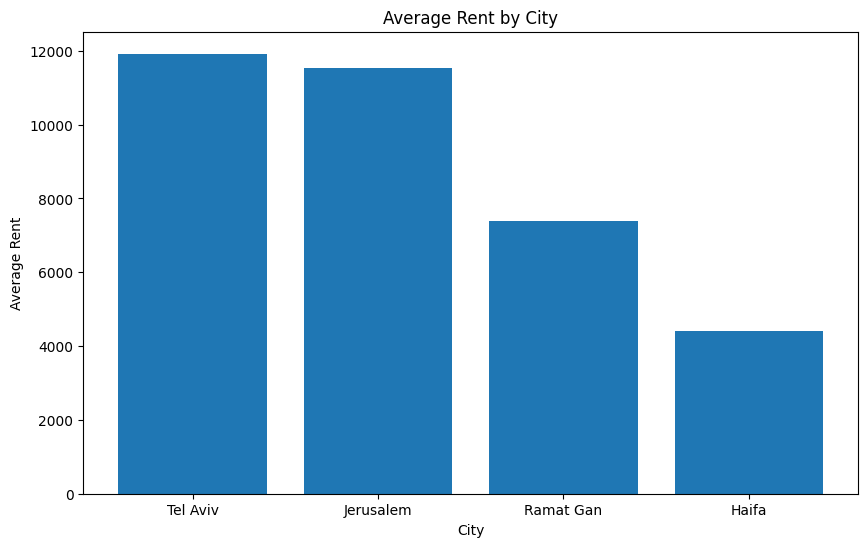

In [57]:
avg_rent_by_city = city_summary.sort_values("average_rent", ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(avg_rent_by_city["City"], avg_rent_by_city["average_rent"])

plt.title("Average Rent by City")
plt.xlabel("City")
plt.ylabel("Average Rent")

plt.show()

## 7. Median Rent by City

Median rent is useful because it is less affected by extreme values than average rent.

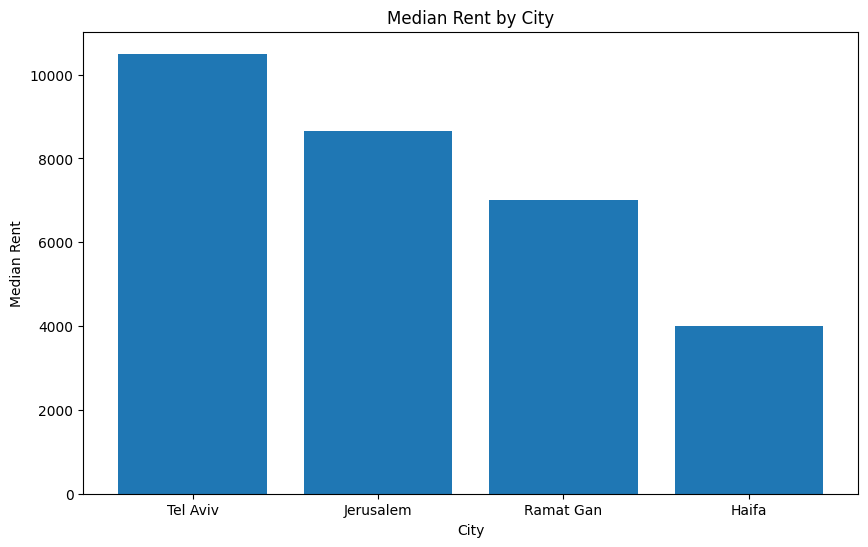

In [58]:
median_rent_by_city = city_summary.sort_values("median_rent", ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(median_rent_by_city["City"], median_rent_by_city["median_rent"])

plt.title("Median Rent by City")
plt.xlabel("City")
plt.ylabel("Median Rent")

plt.show()

## 8. Price per Square Meter by City

Price per square meter allows a more standardized comparison between cities.

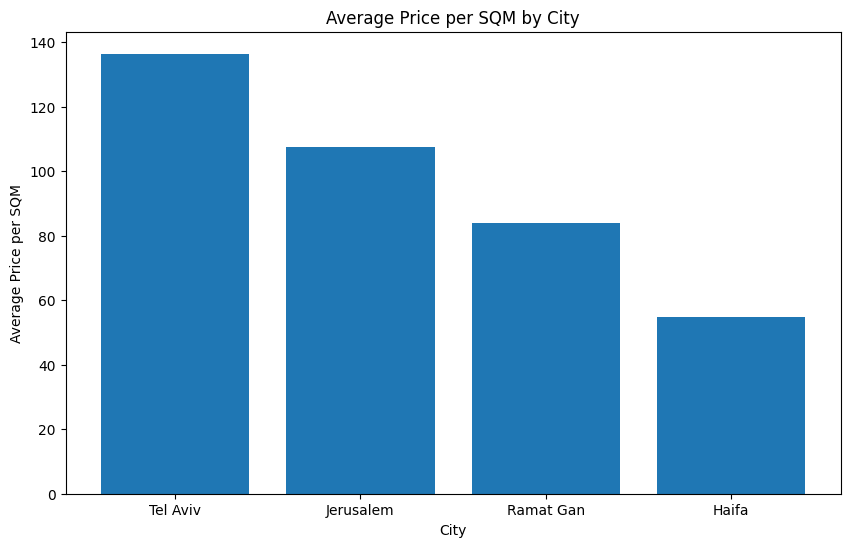

In [59]:
sqm_by_city = city_summary.sort_values("average_price_per_sqm", ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(sqm_by_city["City"], sqm_by_city["average_price_per_sqm"])

plt.title("Average Price per SQM by City")
plt.xlabel("City")
plt.ylabel("Average Price per SQM")

plt.show()

## 9. Price per Room by City

Price per room provides another way to compare rental costs between cities.

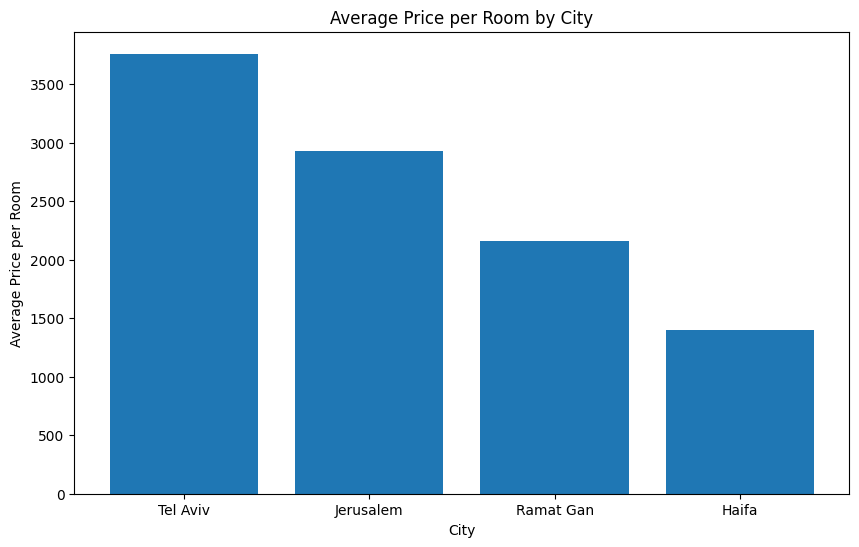

In [60]:
room_by_city = city_summary.sort_values("average_price_per_room", ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(room_by_city["City"], room_by_city["average_price_per_room"])

plt.title("Average Price per Room by City")
plt.xlabel("City")
plt.ylabel("Average Price per Room")

plt.show()

## 10. Rent Price Distribution by City

This section compares rent distributions across cities using boxplots.

/tmp/ipykernel_2916/3323667587.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=cities)


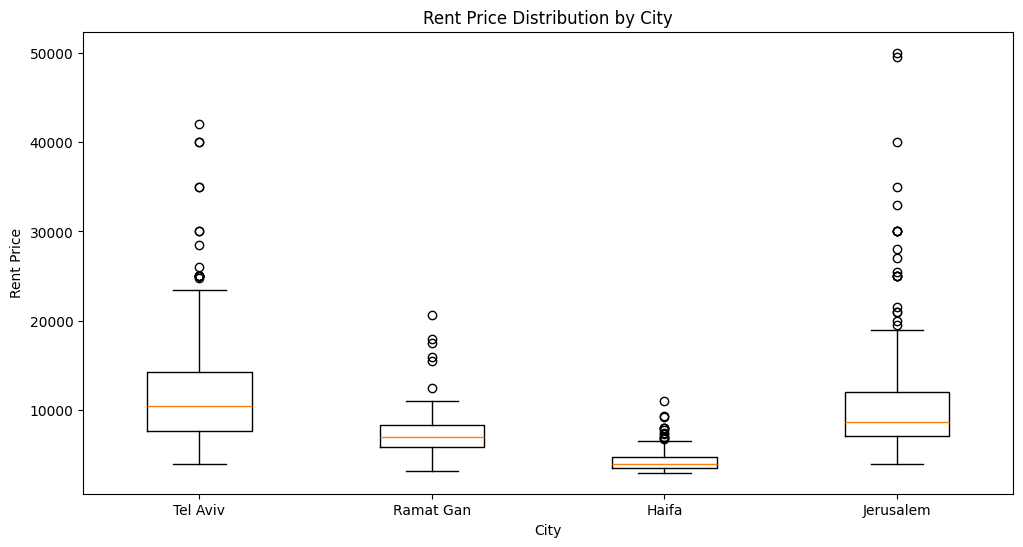

In [61]:
cities = master_rent["City"].unique()

data_to_plot = [
    master_rent[master_rent["City"] == city]["price"]
    for city in cities
]

plt.figure(figsize=(12, 6))
plt.boxplot(data_to_plot, labels=cities)

plt.title("Rent Price Distribution by City")
plt.xlabel("City")
plt.ylabel("Rent Price")

plt.show()

## 11. Cheapest Neighborhoods Across All Cities

This analysis identifies the cheapest neighborhoods across the full dataset.

To avoid unreliable averages, I only include neighborhoods with at least 5 listings.

In [62]:
neighborhood_counts = (
    master_rent
    .groupby(["City", "Neighborhood"])
    .size()
    .reset_index(name="listings")
)

neighborhood_counts.head()

,City,Neighborhood,listings
0,Haifa,Abbas,1
1,Haifa,Ahuza,1
2,Haifa,Carmelia,1
3,Haifa,Central Carmel,22
4,Haifa,Downtown Haifa,7


In [63]:
neighborhood_summary = (
    master_rent
    .groupby(["City", "Neighborhood"])
    .agg(
        listings=("price", "count"),
        average_rent=("price", "mean"),
        median_rent=("price", "median"),
        average_price_per_sqm=("price_per_sqm", "mean")
    )
    .reset_index()
)

neighborhood_summary = neighborhood_summary[
    neighborhood_summary["listings"] >= 5
]

neighborhood_summary[
    ["average_rent", "median_rent", "average_price_per_sqm"]
] = neighborhood_summary[
    ["average_rent", "median_rent", "average_price_per_sqm"]
].round(2)

neighborhood_summary.head()

,City,Neighborhood,listings,average_rent,median_rent,average_price_per_sqm
3,Haifa,Central Carmel,22,5622.73,4600.0,64.22
4,Haifa,Downtown Haifa,7,4075.71,4200.0,58.26
6,Haifa,Hadar HaCarmel,26,3703.85,3500.0,50.17
9,Haifa,Neve Shaanan,15,3863.33,3800.0,47.56
10,Haifa,North Carmel,8,6637.50,6500.0,70.62


In [64]:
cheapest_neighborhoods = neighborhood_summary.sort_values("median_rent").head(15)

cheapest_neighborhoods

,City,Neighborhood,listings,average_rent,median_rent,average_price_per_sqm
6,Haifa,Hadar HaCarmel,26,3703.85,3500.0,50.17
15,Haifa,Upper Hadar,12,3783.33,3625.0,50.20
9,Haifa,Neve Shaanan,15,3863.33,3800.0,47.56
17,Haifa,West Carmel,13,4146.15,4000.0,61.45
4,Haifa,Downtown Haifa,7,4075.71,4200.0,58.26
18,Haifa,Yizre'eliya,13,4234.62,4300.0,50.99
3,Haifa,Central Carmel,22,5622.73,4600.0,64.22
88,Tel Aviv,Neve Shaanan,9,6144.44,5500.0,111.74
52,Ramat Gan,HaGefen,6,6241.67,5875.0,80.30
59,Ramat Gan,Negba Complex,7,5900.00,6000.0,65.29


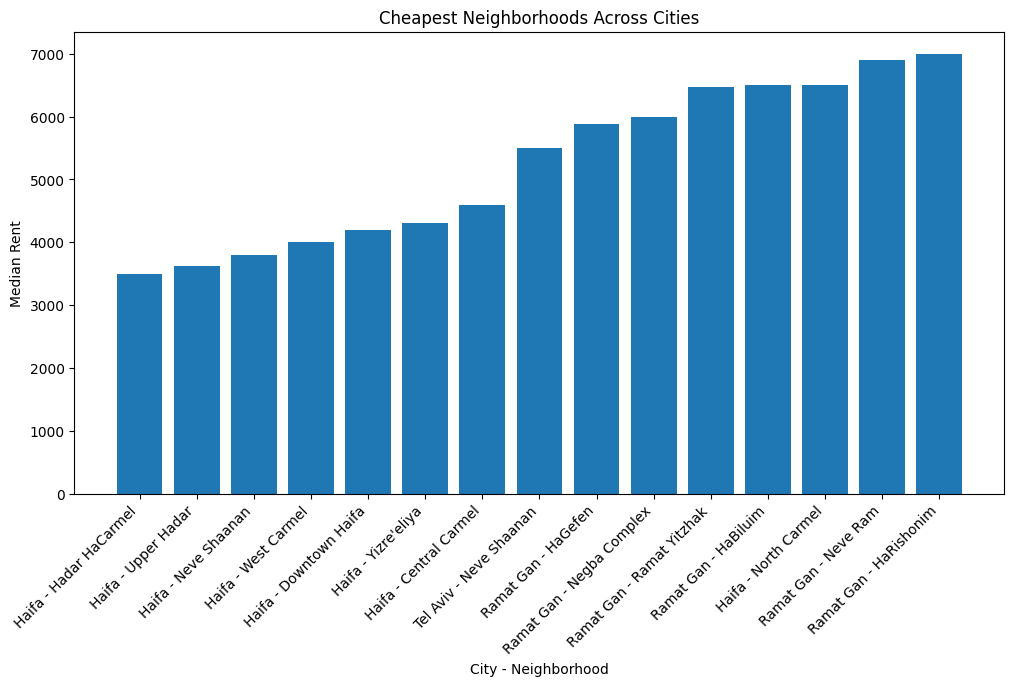

In [65]:
cheapest_labels = (
    cheapest_neighborhoods["City"] + " - " + cheapest_neighborhoods["Neighborhood"]
)

plt.figure(figsize=(12, 6))
plt.bar(cheapest_labels, cheapest_neighborhoods["median_rent"])

plt.title("Cheapest Neighborhoods Across Cities")
plt.xlabel("City - Neighborhood")
plt.ylabel("Median Rent")

plt.xticks(rotation=45, ha="right")
plt.show()

## 12. Most Expensive Neighborhoods Across All Cities

This analysis identifies the most expensive neighborhoods across the full dataset.

Only neighborhoods with at least 5 listings are included.

In [66]:
most_expensive_neighborhoods = (
    neighborhood_summary
    .sort_values("median_rent", ascending=False)
    .head(15)
)

most_expensive_neighborhoods

,City,Neighborhood,listings,average_rent,median_rent,average_price_per_sqm
91,Tel Aviv,New North North,34,16414.71,14750.0,150.73
89,Tel Aviv,Neve Tzedek,6,16666.67,14500.0,173.62
90,Tel Aviv,New North - Kikar HaMedina,9,15355.56,13000.0,119.53
98,Tel Aviv,Old North Southwest,29,12089.66,12900.0,140.11
24,Jerusalem,German Colony,9,17938.89,12000.0,124.09
45,Jerusalem,Talbiya,7,17714.29,12000.0,129.06
95,Tel Aviv,Old North Central,6,13366.67,11000.0,138.00
84,Tel Aviv,Lev Tel Aviv,39,12200.26,10900.0,142.38
29,Jerusalem,Katamon A-F,5,12900.00,10500.0,115.26
97,Tel Aviv,Old North Southeast,35,11142.86,10500.0,135.86


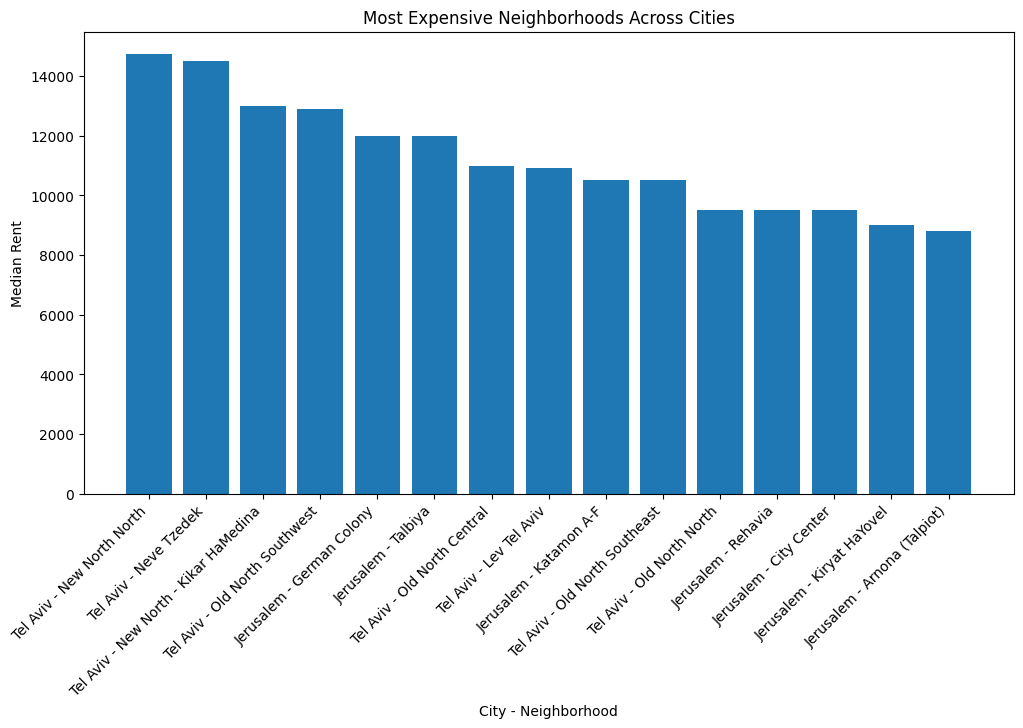

In [67]:
expensive_labels = (
    most_expensive_neighborhoods["City"] + " - " + most_expensive_neighborhoods["Neighborhood"]
)

plt.figure(figsize=(12, 6))
plt.bar(expensive_labels, most_expensive_neighborhoods["median_rent"])

plt.title("Most Expensive Neighborhoods Across Cities")
plt.xlabel("City - Neighborhood")
plt.ylabel("Median Rent")

plt.xticks(rotation=45, ha="right")
plt.show()

## 13. Export Master Dataset

Finally, I export the combined master dataset and summary tables.

These files will be used later for Tableau and the final dashboard.

In [68]:
master_rent.to_csv("master_rent_dataset.csv", index=False)
city_summary.to_csv("city_rent_summary.csv", index=False)
neighborhood_summary.to_csv("neighborhood_rent_summary.csv", index=False)

print("Files exported successfully.")

Files exported successfully.


In [70]:
from google.colab import files

files.download("master_rent_dataset.csv")
files.download("city_rent_summary.csv")
files.download("neighborhood_rent_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>